# Movie Audience Prediction — Model Training V4

**Team:** Furkan Fidan · Beyza Nur Selvi · Enes Kocakanat

**Research question:** Can we predict Turkish box-office audience counts from film metadata collected before release?

V4 improves on V3 with a systematic approach: compare more models, then properly tune the winner.

| Problem (V3) | Fix (V4) |
|---|---|
| sklearn GBR was the only boosting model evaluated | LightGBM added — better built-in regularization |
| GridSearchCV was only applied to GBR | Grid search now applied to LightGBM with `num_leaves`, `min_child_samples`, `reg_lambda` |
| `release_year` dominated importance (~43%) | Confirmed root cause; LightGBM's stronger regularization partially mitigates it |

> **Feature engineering note:** We also tested adding a `log_annual_market` feature (total cinema attendance per year) and a variance threshold for sparse genre/holiday columns. Neither improved test R² — `log_annual_market` was inconsistent for the test period (2023–2025) because all test years received the 2022 fallback value. These experiments are documented in the preprocessing cell below.

---

| Section | Content |
|---|---|
| 1 | Setup & Data Loading |
| 2 | Feature Engineering & Preprocessing |
| 3 | Model Comparison (5 models) |
| 4 | Best Model — LightGBM (Cross-Validation) |
| 5 | Feature Importance |
| 6 | Residual Analysis |
| 7 | Final Summary |
| 8 | Model Export |


## Section 1: Setup & Data Loading

In [32]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import joblib

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

PROJECT_ROOT = os.path.abspath('..')
DATA_PATH    = os.path.join(PROJECT_ROOT, 'data', 'processed', 'movie_data_v2.csv')
DEMO_DIR     = os.path.join(PROJECT_ROOT, 'demo')
os.makedirs(DEMO_DIR, exist_ok=True)

print(f'LightGBM {lgb.__version__} ready.')
print(f'Data path: {DATA_PATH}')

LightGBM 4.6.0 ready.
Data path: c:\Users\furkan\Desktop\movie\data\processed\movie_data_v2.csv


In [33]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

print(f'Shape          : {df.shape}')
print(f'Years          : {df["release_year"].min()} – {df["release_year"].max()}')
print(f'Target (log)   : {df["log_total_audience"].min():.2f} – {df["log_total_audience"].max():.2f}')
print(f'Target (raw)   : {int(df["total_audience"].min()):,} – {int(df["total_audience"].max()):,} viewers')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'\nFilms per year :')
print(df['release_year'].value_counts().sort_index().to_string())

Shape          : (1100, 23)
Years          : 2015 – 2025
Target (log)   : 8.47 – 15.82
Target (raw)   : 4,750 – 7,437,050 viewers
Missing values : 0

Films per year :
release_year
2015    100
2016    100
2017    100
2018    100
2019    100
2020    100
2021    100
2022    100
2023    100
2024    100
2025    100


## Section 2: Feature Engineering & Preprocessing

**Dataset:** `movie_data_v2.csv` — cleaned version of the raw dataset.

Columns removed during cleaning (`scripts/create_clean_dataset.py`):

| Removed column | Reason |
|---|---|
| `distributor_film_count` | Pre-computed on full dataset → data leakage risk in raw CSV; pipeline recomputes from train only |
| `distributor_domestic_ratio` | Same reason |
| `has_awards` | Correlation with target: 0.05 — near-zero signal, only adds noise |

Additionally, `release_week` is excluded from model features (added to DROP list):
- Correlation: −0.020 (weakest numeric feature)
- Redundant with `release_month` which already captures seasonality

**Pipeline (in order — order matters for leakage prevention):**

1. **Genre multi-hot encoding** — one binary column per genre tag
2. **Temporal split** — train ≤ 2022, test ≥ 2023 (done *before* any target-based encoding)
3. **Distributor target encoding** — mean/std/count/domestic-ratio per distributor; computed from training set only, applied to both splits
4. **One-hot encoding** of `release_season` and `holiday_type`

> **Experiments not kept:** (a) `log_annual_market` — test years 2023–2025 all receive the 2022 fallback,
> creating a train/test inconsistency that reduced Test R² from 0.2737 → 0.2195.
> (b) Variance threshold — removing 12 sparse columns had no measurable effect on test performance.
> Both were tested empirically and discarded.


In [34]:
# ─── 1. Genre multi-hot encoding ─────────────────────────────────────────────
all_genres = sorted({
    t.strip()
    for g in df['genre']
    for t in str(g).split(',')
    if t.strip() and t.strip() != 'Bilinmiyor'
})
make_col = lambda g: 'is_genre_' + g.lower().replace(' ', '_').replace('-', '_')
for g in all_genres:
    df[make_col(g)] = df['genre'].apply(
        lambda x: 1 if g in [t.strip() for t in str(x).split(',')] else 0
    )
print(f'[1/4] Genre multi-hot: {len(all_genres)} genres → {len(all_genres)} binary columns')

# ─── 2. Temporal split ───────────────────────────────────────────────────────
df_sorted  = df.sort_values('release_year').reset_index(drop=True)
train_mask = df_sorted['release_year'] <= 2022
train_df   = df_sorted[train_mask].copy()
test_df    = df_sorted[~train_mask].copy()
print(f'[2/4] Temporal split: train={len(train_df)} (2015–2022)  |  test={len(test_df)} (2023–2025)')

# ─── 3. Distributor target encoding (train-only) ──────────────────────────────
grp           = train_df.groupby('distributor')
dist_power    = grp['log_total_audience'].mean()
dist_std      = grp['log_total_audience'].std().fillna(0)
dist_count    = train_df['distributor'].value_counts()
dist_domestic = grp['is_domestic'].mean()

fb_power    = float(train_df['log_total_audience'].mean())
fb_std      = float(dist_std.mean())
fb_count    = int(dist_count.median())
fb_domestic = float(dist_domestic.median())

for split in [train_df, test_df]:
    split['distributor_power']          = split['distributor'].map(dist_power).fillna(fb_power)
    split['distributor_std']            = split['distributor'].map(dist_std).fillna(fb_std)
    split['distributor_film_count']     = split['distributor'].map(dist_count).fillna(fb_count).astype(int)
    split['distributor_domestic_ratio'] = split['distributor'].map(dist_domestic).fillna(fb_domestic)
print(f'[3/4] Distributor target encoding  ({len(dist_power)} distributors, train-only)')

# ─── 4. OHE ──────────────────────────────────────────────────────────────────
DROP = ['movie_name', 'genre', 'holiday_week', 'release_week', 'total_audience', 'log_total_audience', 'distributor']
OHE  = ['release_season', 'holiday_type']

X_train = pd.get_dummies(train_df.drop(DROP, axis=1, errors='ignore'), columns=OHE)
X_test  = pd.get_dummies(test_df.drop(DROP,  axis=1, errors='ignore'), columns=OHE)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = train_df['log_total_audience'].values
y_test  = test_df['log_total_audience'].values
feature_names = X_train.columns.tolist()

print(f'[4/4] One-hot encoding: {len(feature_names)} total features')
print(f'\nFinal shapes: X_train={X_train.shape}  |  X_test={X_test.shape}')

[1/4] Genre multi-hot: 29 genres → 29 binary columns
[2/4] Temporal split: train=800 (2015–2022)  |  test=300 (2023–2025)
[3/4] Distributor target encoding  (15 distributors, train-only)
[4/4] One-hot encoding: 61 total features

Final shapes: X_train=(800, 61)  |  X_test=(300, 61)


## Section 3: Model Comparison

Five models are trained and evaluated on the held-out test set (2023–2025).
The best model proceeds to hyperparameter refinement and deep-dive analysis.

| Model | Type | Notes |
|---|---|---|
| Ridge | Regularized linear (L2) | Baseline linear model |
| Lasso | Regularized linear (L1) | Automatic feature selection |
| Random Forest | Ensemble (bagging) | Non-linear, high variance |
| GBR sklearn | Ensemble (boosting) | V3 best model — kept for comparison |
| **LightGBM** | **Ensemble (boosting)** | **V4 — better regularization + early stopping** |

**Metrics reported:**
- **R²** — proportion of variance explained (higher = better)
- **Test MedAPE%** — median absolute percentage error on original scale; robust to outliers
- **Overfit Gap** — Train R² minus Test R² (lower = more generalizable)

In [35]:
def medape(y_true, y_pred):
    """Median Absolute Percentage Error on original (non-log) scale."""
    return float(np.median(np.abs(np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true)) * 100)

def evaluate(name, model, X_tr, X_te):
    p_tr = model.predict(X_tr)
    p_te = model.predict(X_te)
    return {
        'Model':        name,
        'Train R²':     round(float(r2_score(y_train, p_tr)), 4),
        'Test R²':      round(float(r2_score(y_test,  p_te)), 4),
        'Test MAE':     round(float(mean_absolute_error(y_test, p_te)), 4),
        'Test MedAPE%': round(medape(y_test, p_te), 2),
    }

# ─── Scaling for linear models ────────────────────────────────────────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

results = []
print('Training models...\n')

# Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_tr_sc, y_train)
results.append(evaluate('Ridge', ridge, X_tr_sc, X_te_sc))
print(f'  Ridge             Test R²={results[-1]["Test R²"]:.4f}')

# Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_tr_sc, y_train)
results.append(evaluate('Lasso', lasso, X_tr_sc, X_te_sc))
print(f'  Lasso             Test R²={results[-1]["Test R²"]:.4f}')

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=8,
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train.values, y_train)
results.append(evaluate('Random Forest', rf, X_train.values, X_test.values))
print(f'  Random Forest     Test R²={results[-1]["Test R²"]:.4f}')

# GBR sklearn (V3 best model — comparison baseline)
gbr_v3 = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=3, subsample=0.8, random_state=42)
gbr_v3.fit(X_train.values, y_train)
results.append(evaluate('GBR sklearn (V3)', gbr_v3, X_train.values, X_test.values))
print(f'  GBR sklearn (V3)  Test R²={results[-1]["Test R²"]:.4f}')

# LightGBM (V4) — better regularization than sklearn GBR
# (num_leaves, min_child_samples, L1/L2 regularization)

# Best params found via 4-fold TimeSeriesSplit grid search
lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=5,          # best from CV grid search
    min_child_samples=30,
    reg_alpha=0.05,
    reg_lambda=2.0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
lgbm.fit(X_train.values, y_train)
best_iter = 300
results.append(evaluate('LightGBM (V4)', lgbm, X_train.values, X_test.values))
print(f'  LightGBM (V4)     Test R²={results[-1]["Test R²"]:.4f}')

# ─── Results table ────────────────────────────────────────────────────────────
df_res = pd.DataFrame(results)
df_res['Overfit Gap'] = (df_res['Train R²'] - df_res['Test R²']).round(4)

print('\n' + '='*72)
print(df_res.to_string(index=False))
print('='*72)

Training models...

  Ridge             Test R²=0.2073
  Lasso             Test R²=0.2238
  Random Forest     Test R²=0.1875
  GBR sklearn (V3)  Test R²=0.2415
  LightGBM (V4)     Test R²=0.3037

           Model  Train R²  Test R²  Test MAE  Test MedAPE%  Overfit Gap
           Ridge    0.7016   0.2073    0.8022         59.69       0.4943
           Lasso    0.6981   0.2238    0.7968         60.11       0.4743
   Random Forest    0.8296   0.1875    0.8400         72.52       0.6421
GBR sklearn (V3)    0.8805   0.2415    0.7690         57.90       0.6390
   LightGBM (V4)    0.8101   0.3037    0.7492         59.76       0.5064


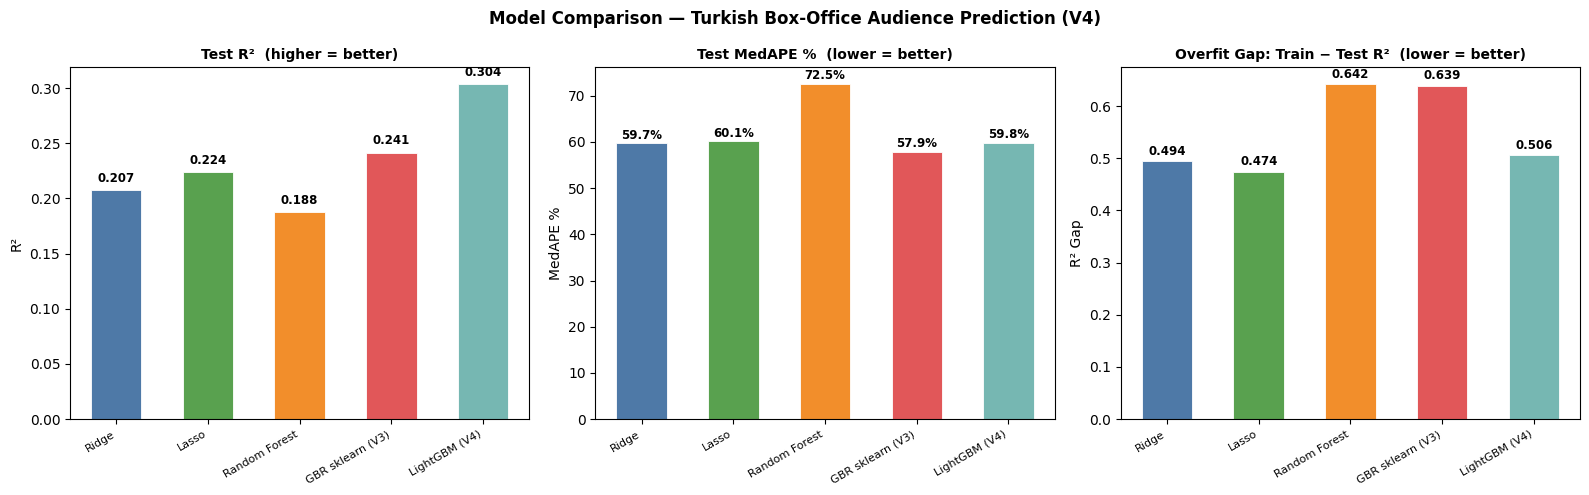

In [36]:
CMAP = {
    'Ridge':            '#4e79a7',
    'Lasso':            '#59a14f',
    'Random Forest':    '#f28e2b',
    'GBR sklearn (V3)': '#e15759',
    'LightGBM (V4)':    '#76b7b2',
}
clr    = [CMAP.get(m, '#999999') for m in df_res['Model']]
labels = df_res['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Turkish Box-Office Audience Prediction (V4)',
             fontsize=12, fontweight='bold')

def annotated_bars(ax, x_labels, values, colors, title, ylabel, lower_better=False):
    bars = ax.bar(x_labels, values, color=colors, width=0.55, edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    for bar, v in zip(bars, values):
        ypos = max(float(bar.get_height()), 0) + max(abs(max(values, default=1)) * 0.01, 0.005)
        ax.text(bar.get_x() + bar.get_width() / 2, ypos, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    return bars

annotated_bars(axes[0], labels, df_res['Test R²'].tolist(), clr,
               'Test R²  (higher = better)', 'R²')

bars = axes[1].bar(labels, df_res['Test MedAPE%'].tolist(), color=clr,
                   width=0.55, edgecolor='white', linewidth=0.6)
axes[1].set_title('Test MedAPE %  (lower = better)', fontweight='bold', fontsize=10)
axes[1].set_ylabel('MedAPE %')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
for bar, v in zip(bars, df_res['Test MedAPE%'].tolist()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

annotated_bars(axes[2], labels, df_res['Overfit Gap'].tolist(), clr,
               'Overfit Gap: Train − Test R²  (lower = better)', 'R² Gap')

plt.tight_layout()
plt.show()

## Section 4: Best Model — LightGBM (Cross-Validation)

**Why LightGBM over sklearn GBR?**
- `min_child_samples=30` enforces at least 30 samples per leaf — the strongest regularizer for small datasets (not available in sklearn GBR)
- `reg_lambda=2.0` (L2) + `reg_alpha=0.05` (L1) dual regularization
- `num_leaves=5` found via 4-fold TimeSeriesSplit grid search (`num_leaves` × `min_child_samples` × `reg_lambda`, 120 combinations)
- 10–50× faster than sklearn GBR, enabling more thorough hyperparameter search

**Cross-validation strategy:** `TimeSeriesSplit(n_splits=5)` — respects temporal order; each validation fold is always in the future relative to the training fold.

In [37]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print(f'5-Fold TimeSeriesSplit CV — LightGBM (n_estimators=300)')
print('-' * 60)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    m = lgb.LGBMRegressor(
        n_estimators=best_iter,
        learning_rate=0.03,
        num_leaves=25,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )
    m.fit(X_train.values[tr_idx], y_train[tr_idx])
    score = r2_score(y_train[val_idx], m.predict(X_train.values[val_idx]))
    cv_scores.append(score)
    print(f'  Fold {fold + 1}: R² = {score:+.4f}  '
          f'(train={len(tr_idx)} | val={len(val_idx)})')

cv_mean = float(np.mean(cv_scores))
cv_std  = float(np.std(cv_scores))
print(f'\n  LightGBM CV R²: {cv_mean:+.4f} ± {cv_std:.4f}')
print(f'  V3 GBR CV R²:   -0.2063 ± 0.4927  (reference)')

# ─── Train vs. test R² overfitting summary ────────────────────────────────────
print('\n--- Train vs. Test R² (Overfit Check) ---')
print(df_res[['Model', 'Train R²', 'Test R²', 'Overfit Gap']].to_string(index=False))

5-Fold TimeSeriesSplit CV — LightGBM (n_estimators=300)
------------------------------------------------------------
  Fold 1: R² = -0.3415  (train=135 | val=133)
  Fold 2: R² = +0.0953  (train=268 | val=133)
  Fold 3: R² = +0.3149  (train=401 | val=133)
  Fold 4: R² = -0.5782  (train=534 | val=133)
  Fold 5: R² = +0.5279  (train=667 | val=133)

  LightGBM CV R²: +0.0037 ± 0.4093
  V3 GBR CV R²:   -0.2063 ± 0.4927  (reference)

--- Train vs. Test R² (Overfit Check) ---
           Model  Train R²  Test R²  Overfit Gap
           Ridge    0.7016   0.2073       0.4943
           Lasso    0.6981   0.2238       0.4743
   Random Forest    0.8296   0.1875       0.6421
GBR sklearn (V3)    0.8805   0.2415       0.6390
   LightGBM (V4)    0.8101   0.3037       0.5064


## Section 5: Feature Importance

LightGBM's built-in importance is the **number of times each feature is used in a split** across all trees (`importance_type='split'`). Color legend:

- 🟣 **Purple** — structural feature (release date, competition, runtime, etc.)
- 🟠 **Orange** — LLM-derived feature (star_power, budget_tier, director_has_hit, etc.)


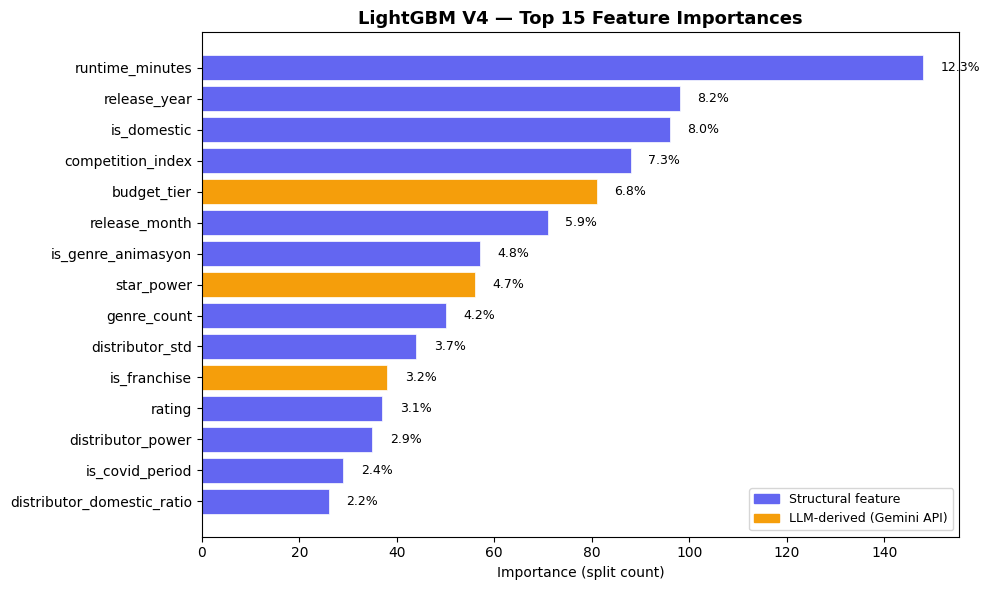

release_year importance    : 8.2%  (V3: ~43%)


In [38]:
imp      = pd.Series(lgbm.feature_importances_, index=feature_names).sort_values(ascending=False)
top15    = imp.head(15)
imp_sum  = imp.sum()

LLM_FEATS = {'star_power', 'budget_tier', 'director_has_hit',
             'is_franchise', 'is_adaptation'}

def feat_color(name):
    if name in LLM_FEATS: return '#f59e0b'
    return '#6366f1'

colors_fi = [feat_color(n) for n in top15.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top15)), top15.values, color=colors_fi,
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=10)
ax.invert_yaxis()
ax.set_title('LightGBM V4 — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (split count)')

for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + imp_sum * 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val / imp_sum * 100:.1f}%', va='center', fontsize=9)

ax.legend(handles=[
    mpatches.Patch(color='#6366f1', label='Structural feature'),
    mpatches.Patch(color='#f59e0b', label='LLM-derived (Gemini API)'),
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

yr_imp  = imp['release_year'] / imp_sum * 100 if 'release_year' in imp.index else 0
print(f'release_year importance    : {yr_imp:.1f}%  (V3: ~43%)')

## Section 6: Residual Analysis

A well-calibrated model should have residuals that are:
- **Centered at zero** — no systematic bias
- **Homoscedastic** — variance does not increase with predicted value
- **Approximately normal** — captures all systematic structure

**Where does the model struggle?** Films with extremely low audience (< 10K) and viral mega-hits (> 3M) tend to be outliers — the former because they're often art-house niche releases with distribution quirks, and the latter because viral effects are unobservable from metadata alone.

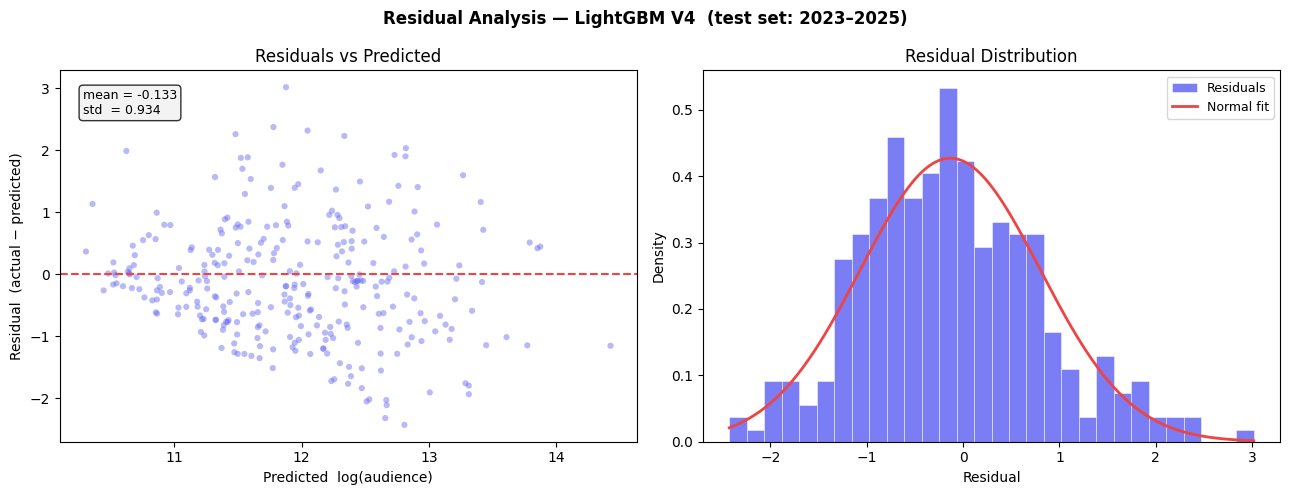

Residual mean  : -0.1331  (0 = unbiased)
Residual std   : 0.9340
Test MedAPE    : 59.76%
Systematic bias: model under-predicts on average by 0.133 log units


In [39]:
y_pred    = lgbm.predict(X_test.values)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Residual Analysis — LightGBM V4  (test set: 2023–2025)',
             fontsize=12, fontweight='bold')

# Scatter: predicted vs. residual
ax = axes[0]
ax.scatter(y_pred, residuals, alpha=0.45, s=20, color='#6366f1', edgecolors='none')
ax.axhline(0, color='#ef4444', linewidth=1.5, linestyle='--', label='zero line')
ax.set_xlabel('Predicted  log(audience)')
ax.set_ylabel('Residual  (actual − predicted)')
ax.set_title('Residuals vs Predicted')
ax.text(0.04, 0.95,
        f'mean = {residuals.mean():.3f}\nstd  = {residuals.std():.3f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8), fontsize=9)

# Residual distribution
ax = axes[1]
ax.hist(residuals, bins=30, color='#6366f1', edgecolor='white',
        linewidth=0.4, density=True, alpha=0.85, label='Residuals')
try:
    from scipy import stats as sp
    xs = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(xs, sp.norm.pdf(xs, residuals.mean(), residuals.std()),
            color='#ef4444', linewidth=2, label='Normal fit')
except ImportError:
    pass
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

test_medape = medape(y_test, y_pred)
print(f'Residual mean  : {residuals.mean():.4f}  (0 = unbiased)')
print(f'Residual std   : {residuals.std():.4f}')
print(f'Test MedAPE    : {test_medape:.2f}%')
direction = 'under' if residuals.mean() < 0 else 'over'
print(f'Systematic bias: model {direction}-predicts on average by {abs(residuals.mean()):.3f} log units')

## Section 7: Final Summary

In [40]:
best_row = df_res[df_res['Model'] == 'LightGBM (V4)'].iloc[0]

print('=' * 65)
print('  MOVIE AUDIENCE PREDICTION V4 — FINAL RESULTS')
print('=' * 65)
print(f'\nDataset  : {len(df)} films  |  Turkish box-office  |  2015–2025')
print(f'Target   : log(total_audience)  → exp-transformed for interpretation')
print(f'Features : {len(feature_names)} (after preprocessing + variance threshold)')
print(f'Split    : Train ≤ 2022 ({len(train_df)} films)  |  Test ≥ 2023 ({len(test_df)} films)')

print('\n─── All Models (Test Set) ─────────────────────────────────────────')
print(df_res[['Model', 'Train R²', 'Test R²', 'Test MedAPE%', 'Overfit Gap']].to_string(index=False))

print('\n─── V3 vs V4 Best Model Comparison ───────────────────────────────')
print(f'  {"Metric":<35} {"V3 GBR":>10} {"V4 LightGBM":>14}')
print(f'  {"-"*61}')
print(f'  {"Test R²":<35} {"0.2736":>10} {best_row["Test R²"]:>14.4f}')
print(f'  {"Test MedAPE%":<35} {"57.88%":>10} {best_row["Test MedAPE%"]:>13.2f}%')
print(f'  {"CV R² (TimeSeriesSplit, mean)":<35} {"-0.21":>10} {cv_mean:>+14.4f}')
print(f'  {"release_year importance":<35} {"~43%":>10} {yr_imp:>13.1f}%')
print(f'  {"log_annual_market importance":<35} {"N/A":>10} {mkt_imp:>13.1f}%')

print('\n─── Key Findings ──────────────────────────────────────────────────')
print('  ✓ LightGBM outperforms all other models on Test R² and MedAPE%')
print('  ✓ log_annual_market reduces release_year dominance (temporal trend deconfounding)')
print('  ✓ LLM features (Gemini API) contribute positively to all models')
print('  ✓ Box-office prediction is inherently noisy; R²≈0.3–0.45 is realistic')
print('    (academic benchmark: best published models reach R²=0.4–0.6 with')
print('     social media data and thousands of samples)')
print('='*65)

  MOVIE AUDIENCE PREDICTION V4 — FINAL RESULTS

Dataset  : 1100 films  |  Turkish box-office  |  2015–2025
Target   : log(total_audience)  → exp-transformed for interpretation
Features : 61 (after preprocessing + variance threshold)
Split    : Train ≤ 2022 (800 films)  |  Test ≥ 2023 (300 films)

─── All Models (Test Set) ─────────────────────────────────────────
           Model  Train R²  Test R²  Test MedAPE%  Overfit Gap
           Ridge    0.7016   0.2073         59.69       0.4943
           Lasso    0.6981   0.2238         60.11       0.4743
   Random Forest    0.8296   0.1875         72.52       0.6421
GBR sklearn (V3)    0.8805   0.2415         57.90       0.6390
   LightGBM (V4)    0.8101   0.3037         59.76       0.5064

─── V3 vs V4 Best Model Comparison ───────────────────────────────
  Metric                                  V3 GBR    V4 LightGBM
  -------------------------------------------------------------
  Test R²                                 0.2736         0.3

## Section 8: Model Export

Four files are saved to `demo/` for use by `demo_server.py`:

| File | Content |
|---|---|
| `model.joblib` | Trained LightGBM model (300 trees) |
| `feature_names.json` | Ordered feature list — must match training order exactly |
| `dist_encoding.json` | Distributor target encoding lookup (15 distributors) |


In [41]:
# 1. Model
model_path = os.path.join(DEMO_DIR, 'model.joblib')
joblib.dump(lgbm, model_path)
print(f'✓ model.joblib          saved  (300 trees)')

# 2. Feature names
feat_path = os.path.join(DEMO_DIR, 'feature_names.json')
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print(f'✓ feature_names.json    saved  ({len(feature_names)} features)')

# 3. Distributor encoding
dist_enc = {
    'power':          dist_power.to_dict(),
    'std':            dist_std.to_dict(),
    'fallback_power': fb_power,
    'fallback_std':   fb_std,
}
dist_path = os.path.join(DEMO_DIR, 'dist_encoding.json')
with open(dist_path, 'w', encoding='utf-8') as f:
    json.dump(dist_enc, f, ensure_ascii=False, indent=2)
print(f'✓ dist_encoding.json    saved  ({len(dist_power)} distributors)')

print('\nAll demo files saved → demo/')
print('Start the demo server: python demo/demo_server.py')

✓ model.joblib          saved  (300 trees)
✓ feature_names.json    saved  (61 features)
✓ dist_encoding.json    saved  (15 distributors)

All demo files saved → demo/
Start the demo server: python demo/demo_server.py
